# Generating the Initial DataFrame 

In this notebooks we generate a dataframe from the excel document containing the thickness and we iterate over the folder with the spectrum samples in _.txt_ format. 15 samples are converted into a DataFrame.

## Used libraries

In [1]:
import pandas as pd
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt 

## Experimental Samples

The thickness for each thin layer has been characterized, their values are in a _.csv_ file.

In [2]:
# Excel 
excel_data = pd.read_csv('../../experimental_samples/Processed_Data/Example_Sample_IA_2_F_30NEW.csv', index_col= 0)
excel_data.shape

(65, 4)

In [3]:
excel_data.head()

,Nombre-Arc,Espesor,Error,Error Porcentual
Nombre,,,,
ANZO49,ANZO49M,870.899965,81.504077,9.358604
ANZO49-1,ANZO491M,589.742792,52.884180,8.967330
ANZO49-2,ANZO492M,758.367170,67.507986,8.901755
ANZO49-3,ANZO493M,801.558241,100.974310,12.597252
ANZO49-4,ANZO494M,835.428770,70.921047,8.489179


In [4]:
# Eliminate the difference between upper and lower case
excel_data['Nombre-Arc'] = excel_data['Nombre-Arc'].str.upper()

## Histograms

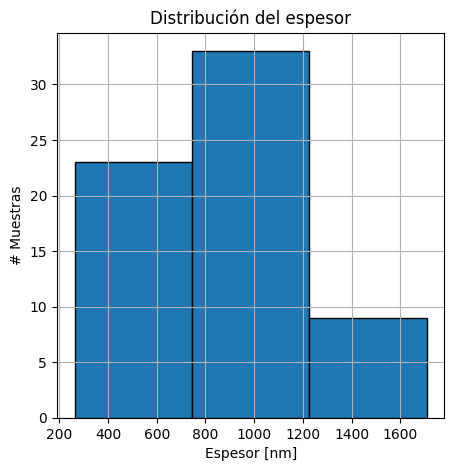

In [5]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Espesor'], bins = 3, edgecolor = 'black')
plt.title('Distribución del espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/bin3.png')
plt.show()

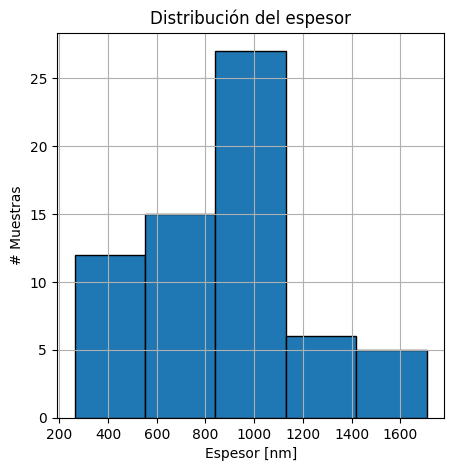

In [6]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Espesor'], bins = 5, edgecolor = 'black')
plt.title('Distribución del espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/bin5.png')
plt.show()

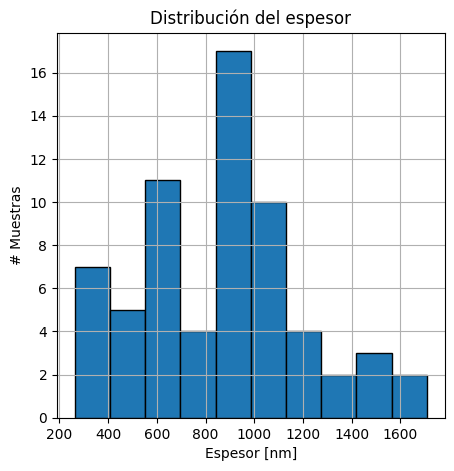

In [7]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Espesor'], bins = 10, edgecolor = 'black')
plt.title('Distribución del espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/bin10.png')
plt.show()

An interesting plot is the Kernel Density Estimation for the Thickness Distribuion. This result will be key in the future. 

In [8]:
import seaborn as sns

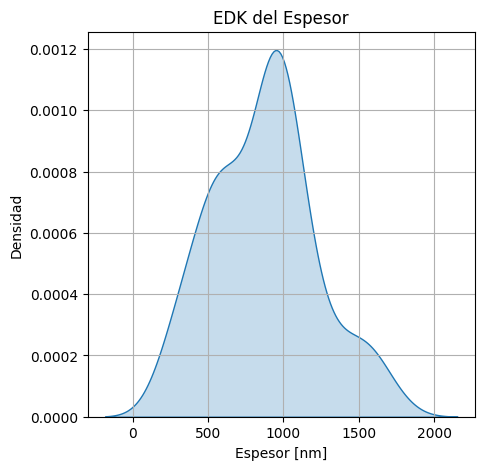

In [9]:
plt.figure(figsize = (5,5))
sns.kdeplot(excel_data['Espesor'], fill='True')
#plt.hist(excel_data['Espesor'], bins = 10, edgecolor = 'black')
plt.title('EDK del Espesor')
plt.grid()
plt.ylabel('Densidad')
plt.xlabel('Espesor [nm]')
#plt.savefig('./images/kde.png')
plt.show()

Where the mean and std values for the thickness are:

In [10]:
np.mean(excel_data['Espesor']), np.std(excel_data['Espesor'])

(np.float64(868.7162244800002), np.float64(338.3780426590364))

Let's now focuse on the Porcentual Error

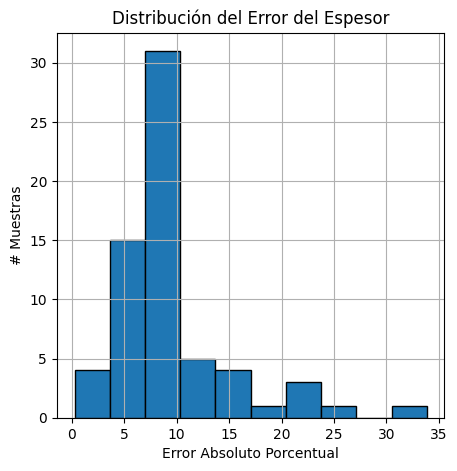

In [11]:
plt.figure(figsize = (5,5))
plt.hist(excel_data['Error Porcentual'], bins = 10, edgecolor = 'black')
plt.title('Distribución del Error del Espesor')
plt.grid()
plt.ylabel('# Muestras')
plt.xlabel('Error Absoluto Porcentual')
#plt.savefig('./images/error1.png')
plt.show()

Where the mean and std values are:

In [12]:
np.mean(excel_data['Error Porcentual']), np.std(excel_data['Error Porcentual'])

(np.float64(9.508145864707691), np.float64(5.601611970994543))

In [13]:
#__df = excel_data[ (excel_data['Espesor'] >=500 ) & (excel_data['Espesor'] <=1500)   ] 
__df = excel_data # This section is useful for selecting just an thickness interval
#__df.head()

Now, we iterate over the SpectrumOrder folder, this folder contains all the experimental samples organized by thickness range [100,200] nm.

In [14]:
# Iteracion de las muestras
path_dataset = Path('../../experimental_samples/Muestra_ANZO67-ANZO69/')
names = []
samples = []
for filename in path_dataset.rglob('*'):
    if filename.suffix == '.txt': 
        try: 
            #print(filename)
            df = np.array(pd.read_csv(filename, sep = ' ', usecols = [0, 1], header = None)[1])
            samples.append(df)
            names.append(filename.name[:-4])
        except Exception as e: 
            print(e)

In [15]:
samples = np.expand_dims( np.array(samples), axis = 2) # Give the correct format 

In [16]:
samples.shape

(15, 911, 1)

In [17]:
len(names), names[:3]

(15, ['ANZO693M', 'ANZO674M', 'ANZO691M'])

In [18]:
_df = pd.DataFrame({
    'Nombre-Arc': names,
    'Espectro': [ [s] for s in samples ]
})

In [19]:
_df.head()

,Nombre-Arc,Espectro
0,ANZO693M,"[[[0.106], [0.154], [0.086999], [0.076], [0.07..."
1,ANZO674M,"[[[0.068], [0.094], [0.029], [0.066], [0.028],..."
2,ANZO691M,"[[[0.019], [0.101], [0.053], [0.067], [0.05], ..."
3,ANZO684M,"[[[0.0], [0.086999], [0.01], [0.077], [0.029],..."
4,ANZO69M,"[[[0.06], [0.149], [0.071], [0.088], [0.049], ..."


This section outputs the samples in the excel file and the sample in the SpectrumOrder folder. In everything's right the values of unique shall be empty.

In [20]:
unique_in_df1 = __df.loc[~__df['Nombre-Arc'].isin(_df['Nombre-Arc']), 'Nombre-Arc']

In [21]:
unique_in_df2 = _df.loc[~_df['Nombre-Arc'].isin(__df['Nombre-Arc']), 'Nombre-Arc']

In [22]:
unique_in_df1

Nombre
ANZO49          ANZO49M
ANZO49-1       ANZO491M
ANZO49-2       ANZO492M
ANZO49-3       ANZO493M
ANZO49-4       ANZO494M
ANZO50          ANZO50M
ANZO50-1A      NZO501AM
ANZO50-2A      NZO502AM
ANZO50-3A      NZO503AM
ANZO50-4A      NZO504AM
ANZO51          ANZO51M
ANZO51-1       ANZO511M
ANZO51-2     ANZO512AM*
ANZO51-3     ANZO513AM*
ANZO51-4     ANZO514AM*
ANZO53         ANZO53M*
ANZO53-1      ANZO531M*
ANZO53-2      ANZO532M*
ANZO53-3      ANZO533M*
ANZO53-4      ANZO534M*
ANZO58          ANZO58M
ANZO58-1       ANZO581M
ANZO58-2       ANZO582M
ANZO58-3       ANZO583M
ANZO58-4       ANZO584M
ANZO59          ANZO59M
ANZO59-1       ANZO591M
ANZO59-2       ANZO592M
ANZO59-3       ANZO593M
ANZO59-4       ANZO594M
ANZO62          ANZO62M
ANZO62-1       ANZO621M
ANZO62-2       ANZO622M
ANZO62-3       ANZO623M
ANZO62-4       ANZO624M
ANZO65          ANZO65M
ANZO65-1       ANZO651M
ANZO65-2       ANZO652M
ANZO65-3       ANZO653M
ANZO65-4       ANZO654M
ANZO66          ANZO66M
ANZO66-1 

In [23]:
unique_in_df2

Series([], Name: Nombre-Arc, dtype: object)

In [24]:
_df.shape

(15, 2)

In [25]:
# Merge de Datasets 
df_junto = pd.merge(__df, _df, on='Nombre-Arc', how='inner')

In [26]:
df_junto.head()

,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO67M,607.62,129.99,21.393305,"[[[0.032], [0.106], [0.011], [0.05], [0.032], ..."
1,ANZO671M,531.47,90.17,16.966150,"[[[0.074], [0.096], [0.047], [0.057], [0.06999..."
2,ANZO672M,517.47,75.50,14.590218,"[[[0.114], [0.12], [0.048], [0.076], [0.064], ..."
3,ANZO673M,612.85,133.60,21.799788,"[[[0.125], [0.15], [0.049], [0.088], [0.074], ..."
4,ANZO674M,597.35,119.26,19.964845,"[[[0.068], [0.094], [0.029], [0.066], [0.028],..."


In [27]:
df_junto['Espesor'] = (df_junto['Espesor'] - 17.897827)/1.1521356

In [28]:
df_junto.head()

,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO67M,511.851359,129.99,21.393305,"[[[0.032], [0.106], [0.011], [0.05], [0.032], ..."
1,ANZO671M,445.756709,90.17,16.966150,"[[[0.074], [0.096], [0.047], [0.057], [0.06999..."
2,ANZO672M,433.605361,75.50,14.590218,"[[[0.114], [0.12], [0.048], [0.076], [0.064], ..."
3,ANZO673M,516.390756,133.60,21.799788,"[[[0.125], [0.15], [0.049], [0.088], [0.074], ..."
4,ANZO674M,502.937478,119.26,19.964845,"[[[0.068], [0.094], [0.029], [0.066], [0.028],..."


In [29]:
df_junto.shape

(15, 5)

We've just created a unique DataFrame with the name, thickness, error and spectrum. Let's save it as a Pickle

In [30]:
df_junto.to_pickle('../../results/dataframe_spectrum_thickness_15.pkl')